### Feature Engineer - MLE2

In [138]:
import pandas as pd
import numpy as np
import uuid
import time
from datetime import datetime
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from loguru import logger

In [48]:
raw_data = pd.read_csv("../data/raw/hotel_bookings.csv")

In [49]:
raw_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [157]:
class FeatureEngineeringProcessor:
    def __init__(self, raw_data: pd.DataFrame, pipeline_name: str) -> None:
        self.raw_data = raw_data
        self.pipeline_name = pipeline_name
        self.feature_table = None

    def impute_scale(self) -> pd.DataFrame:
        """Pipeline que imputa variables numérica y luego las escala, para
        finalmente aplicar PCA y quedarse con N componentes principales"""
        numeric_cols = [
            "lead_time",
            "adults",
            "children",
            "babies",
            "adr"
        ]
        pipe = Pipeline(
            steps = [
                ("imputer_mean", SimpleImputer(strategy= "mean")),
                ("std_scaling", StandardScaler()),
                ("pca", PCA(n_components = 2))
            ]
        )
        return pd.DataFrame(
            pipe.fit_transform(self.raw_data[numeric_cols]),
            columns = ["great_feature1", "great_feature2"]
        )
    
    
    def encode_categoricals(self) -> pd.DataFrame:

        encoded_vars = []
        for var in ["hotel", "market_segment", "reserved_room_type"]: 
            encoder = OneHotEncoder()
            logger.info(f"Codificando con OHE {var}")
            encoded = encoder.fit_transform(self.raw_data[[var]]).toarray()
            cols = [f"{var}_{col}" for col in encoder.categories_[0]]
            _dataframe = pd.DataFrame(
                encoded,
                columns= cols
            )
            encoded_vars.append(_dataframe)
        return pd.concat(encoded_vars, axis= 1)
                                  
        
    def run(self) -> pd.DataFrame:
        # acá podrenmos nuestro código
        logger.info(f"Inicializando pipeline {self.pipeline_name}")

        categorical = self.encode_categoricals()
        numerics = self.impute_scale()

        modeling_dataset = pd.concat([categorical, numerics], axis = 1)
        
        # Dataset Previo al pipeline
        pipe = Pipeline(
            steps = [
                ("feature_selection", VarianceThreshold()),
                ("scaling_robust", RobustScaler())
            ]
        )
        self.feature_table = pd.DataFrame(
            pipe.fit_transform(modeling_dataset),
            columns = modeling_dataset.columns
        )
        self.feature_table["booking_id"] = [str(uuid.uuid4()) for _ in range(self.feature_table.shape[0])]
        self.feature_table["event_timestamp"] = [datetime.now() for _ in range(self.feature_table.shape[0])]
        time.sleep(1)
        self.feature_table["created"] = [datetime.now() for _ in range(self.feature_table.shape[0])]
        self.feature_table["event_timestamp"] = pd.to_datetime(self.feature_table["event_timestamp"], utc=True)
        self.feature_table["created"] = pd.to_datetime(self.feature_table["created"], utc=True)
        
        return self.feature_table

    def write_feature_table(self, filepath: str) -> None:
        """Escribimos la feature table final para modelamiento"""
        if self.feature_table is not None:
            self.feature_table.to_parquet(filepath, index = False)
        else:
            raise Exception("La feature table no ha sido creada")


    

In [51]:
tiempos = pd.Series(raw_data["reservation_status_date"].unique().tolist())
tiempos = pd.to_datetime(tiempos, format = "%Y-%m-%d")
tiempos

0     2015-07-01
1     2015-07-02
2     2015-07-03
3     2015-05-06
4     2015-04-22
         ...    
921   2014-10-17
922   2015-01-20
923   2015-02-17
924   2015-03-10
925   2015-03-23
Length: 926, dtype: datetime64[ns]

### Train - Test Split

In [52]:
TRAIN_SIZE = round(raw_data.shape[0] * 0.8)
TEST_SIZE = raw_data.shape[0] - TRAIN_SIZE

In [53]:
raw_data.sample(5).index

Index([113542, 72539, 110069, 93836, 15007], dtype='int64')

In [54]:
train_indices = raw_data.sample(TRAIN_SIZE).index

In [55]:
test_indices = [i for i in raw_data.index if i not in train_indices]

In [56]:
train_raw_data = raw_data.iloc[train_indices]
test_raw_data = raw_data.iloc[test_indices]

In [57]:
train_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95512 entries, 34990 to 39394
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           95512 non-null  object 
 1   is_canceled                     95512 non-null  int64  
 2   lead_time                       95512 non-null  int64  
 3   arrival_date_year               95512 non-null  int64  
 4   arrival_date_month              95512 non-null  object 
 5   arrival_date_week_number        95512 non-null  int64  
 6   arrival_date_day_of_month       95512 non-null  int64  
 7   stays_in_weekend_nights         95512 non-null  int64  
 8   stays_in_week_nights            95512 non-null  int64  
 9   adults                          95512 non-null  int64  
 10  children                        95509 non-null  float64
 11  babies                          95512 non-null  int64  
 12  meal                            9

In [58]:
train_raw_data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,95509.000000,95512.000000,95512.000000,95512.000000,95512.000000,95512.000000,82474.000000,5396.000000,95512.000000,95512.000000,95512.000000,95512.000000
mean,0.371576,104.295596,2016.156567,27.195850,15.798057,0.926679,2.498367,1.856563,0.104095,0.007947,0.031828,0.086785,0.134685,0.221051,86.614388,189.331727,2.324054,101.972131,0.062579,0.569907
std,0.483229,107.192074,0.708329,13.580536,8.779360,0.996163,1.898244,0.575715,0.399395,0.095494,0.175544,0.838984,1.478507,0.655346,110.704897,131.970577,17.681261,48.262302,0.246107,0.793668
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,709.000000,2017.000000,53.000000,31.000000,18.000000,42.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,510.000000,8.000000,5.000000


In [15]:
encoder = OneHotEncoder()
encoded =encoder.fit_transform(train_raw_data[["hotel"]])

encoder.categories_[0]

array(['City Hotel', 'Resort Hotel'], dtype=object)

In [59]:
processor = FeatureEngineeringProcessor(
    raw_data = train_raw_data,
    pipeline_name = "DSRP MLE2 Feature Engineering"
)
processor.encode_categoricals()

2026-04-10 11:46:08.302 | INFO     | __main__:encode_categoricals:34 - Codificando con OHE hotel
2026-04-10 11:46:08.329 | INFO     | __main__:encode_categoricals:34 - Codificando con OHE market_segment
2026-04-10 11:46:08.344 | INFO     | __main__:encode_categoricals:34 - Codificando con OHE reserved_room_type


,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,reserved_room_type_A,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95507,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
95508,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95509,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95510,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
processor.impute_scale()

,pc1,pc2
0,4.111687,-1.424922
1,-1.036932,-1.479028
2,-0.946969,1.095924
3,0.287579,0.939670
4,-0.393979,-0.322511
...,...,...
95507,0.114251,1.172572
95508,-1.433444,0.481058
95509,-0.396080,-0.280160
95510,0.205784,-0.515083


In [158]:
train_processor = FeatureEngineeringProcessor(
    raw_data = train_raw_data,
    pipeline_name = "DSRP MLE2 Feature Engineering"
)
train_processor.run()

2026-04-11 08:40:58.851 | INFO     | __main__:run:48 - Inicializando pipeline DSRP MLE2 Feature Engineering
2026-04-11 08:40:58.852 | INFO     | __main__:encode_categoricals:35 - Codificando con OHE hotel
2026-04-11 08:40:58.879 | INFO     | __main__:encode_categoricals:35 - Codificando con OHE market_segment
2026-04-11 08:40:58.890 | INFO     | __main__:encode_categoricals:35 - Codificando con OHE reserved_room_type


,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,...,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,great_feature1,great_feature2,booking_id,event_timestamp,created
0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.076314,-0.289116,8620e48c-5f04-43cb-b956-14eff8a5466d,2026-04-11 08:40:59.102024+00:00,2026-04-11 08:41:00.141112+00:00
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.435578,0.137010,8da82953-3064-40a9-bf7b-86c040f56aeb,2026-04-11 08:40:59.102027+00:00,2026-04-11 08:41:00.141126+00:00
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.744242,-0.320501,85229c92-a177-4405-9949-74e6a43ba439,2026-04-11 08:40:59.102027+00:00,2026-04-11 08:41:00.141127+00:00
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.959966,0.999208,edbb2796-2e9f-4d5c-9505-75cae5049662,2026-04-11 08:40:59.102027+00:00,2026-04-11 08:41:00.141128+00:00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,5.302648,-1.574997,7348b117-c927-4837-ac46-117233746d7b,2026-04-11 08:40:59.102028+00:00,2026-04-11 08:41:00.141128+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95507,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.794937,-0.835040,9c460daf-e583-4009-8c3a-177ab507a65c,2026-04-11 08:40:59.118488+00:00,2026-04-11 08:41:00.196068+00:00
95508,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.033893,-0.028426,8c22b340-9313-4813-b40b-b431e6ccbcd4,2026-04-11 08:40:59.118488+00:00,2026-04-11 08:41:00.196068+00:00
95509,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.153463,1.048928,f9968f6c-7f5a-4d24-805a-d0f488d1aaa2,2026-04-11 08:40:59.118488+00:00,2026-04-11 08:41:00.196068+00:00
95510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.824912,-0.287809,04b49045-d5be-4b37-9cc6-fa5e75fbec43,2026-04-11 08:40:59.118489+00:00,2026-04-11 08:41:00.196069+00:00


In [159]:
train_processor.write_feature_table(
    filepath= "../feast_service/dsrp_fs_mle_2_project/feature_repo/data/bookings_feature_table.parquet"
)

In [160]:
v = pd.read_parquet("../feast_service/dsrp_fs_mle_2_project/feature_repo/data/bookings_feature_table.parquet").head()

In [161]:
v

,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,...,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,great_feature1,great_feature2,booking_id,event_timestamp,created
0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.076314,-0.289116,8620e48c-5f04-43cb-b956-14eff8a5466d,2026-04-11 08:40:59.102024+00:00,2026-04-11 08:41:00.141112+00:00
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.435578,0.137010,8da82953-3064-40a9-bf7b-86c040f56aeb,2026-04-11 08:40:59.102027+00:00,2026-04-11 08:41:00.141126+00:00
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.744242,-0.320501,85229c92-a177-4405-9949-74e6a43ba439,2026-04-11 08:40:59.102027+00:00,2026-04-11 08:41:00.141127+00:00
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.959966,0.999208,edbb2796-2e9f-4d5c-9505-75cae5049662,2026-04-11 08:40:59.102027+00:00,2026-04-11 08:41:00.141128+00:00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,5.302648,-1.574997,7348b117-c927-4837-ac46-117233746d7b,2026-04-11 08:40:59.102028+00:00,2026-04-11 08:41:00.141128+00:00


In [65]:
test_processor = FeatureEngineeringProcessor(
    raw_data = test_raw_data,
    pipeline_name = "DSRP MLE2 Feature Engineering - TEST"
)
test_processor.run()

2026-04-10 11:57:17.422 | INFO     | __main__:run:47 - Inicializando pipeline DSRP MLE2 Feature Engineering - TEST
2026-04-10 11:57:17.424 | INFO     | __main__:encode_categoricals:34 - Codificando con OHE hotel
2026-04-10 11:57:17.435 | INFO     | __main__:encode_categoricals:34 - Codificando con OHE market_segment
2026-04-10 11:57:17.442 | INFO     | __main__:encode_categoricals:34 - Codificando con OHE reserved_room_type


,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,...,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,great_feature1,great_feature2
0,-1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.199406,4.586673
1,-1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.121740,-1.128503
2,-1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.120811,-1.089546
3,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.110831,-0.248776
4,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.110831,-0.248776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.026054,0.812637
23874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.989076,-0.048266
23875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.151810,0.860079
23876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.871392,1.006581


In [ ]:
train

### Trabajando con Feast

In [75]:
str(uuid.uuid4())

'c5594367-2e18-4a90-8ca4-0cbd324a4f40'

In [112]:
from feast import FeatureStore

In [113]:
fs = FeatureStore("../feast_service/dsrp_fs_mle_2_project/feature_repo/")

In [114]:
feature_service = fs.get_feature_service("dsrp_feature_service")

In [101]:
features_retrieved = fs.get_historical_features(features = feature_service, entity_df= train_processor.feature_table)


In [107]:
features_retrieved.to_df()

AttributeError: 'DataFrame' object has no attribute 'persist'

In [105]:
train_processor.feature_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95512 entries, 0 to 95511
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   hotel_City Hotel              95512 non-null  float64       
 1   hotel_Resort Hotel            95512 non-null  float64       
 2   market_segment_Aviation       95512 non-null  float64       
 3   market_segment_Complementary  95512 non-null  float64       
 4   market_segment_Corporate      95512 non-null  float64       
 5   market_segment_Direct         95512 non-null  float64       
 6   market_segment_Groups         95512 non-null  float64       
 7   market_segment_Offline TA/TO  95512 non-null  float64       
 8   market_segment_Online TA      95512 non-null  float64       
 9   market_segment_Undefined      95512 non-null  float64       
 10  reserved_room_type_A          95512 non-null  float64       
 11  reserved_room_type_B        

In [162]:
fs = FeatureStore("../feast_service/dsrp_fs_mle_2_project/feature_repo/")

In [167]:
entity_df = pd.DataFrame.from_dict(
    {"booking_id": ["8620e48c-5f04-43cb-b956-14eff8a5466d", "8da82953-3064-40a9-bf7b-86c040f56aeb"],

    #"great_feature1": [0.012, 12],
    #"great_feature2": [200, 300 ],
    "kpi1": [2, 5],
    "kpi2": [10, 10]},
    
)
entity_df["event_timestamp"] = pd.to_datetime("now", utc= True)
entity_df


,booking_id,kpi1,kpi2,event_timestamp
0,8620e48c-5f04-43cb-b956-14eff8a5466d,2,10,2026-04-11 14:25:57.900589+00:00
1,8da82953-3064-40a9-bf7b-86c040f56aeb,5,10,2026-04-11 14:25:57.900589+00:00


In [168]:
fs.get_historical_features(
    entity_df = entity_df,
    features = [
        "pc_booking_view:great_feature1",
        "pc_booking_view:great_feature2",
        "great_feature_view:great_feature1_kpi1",
        "great_feature_view:great_feature2_kpi2"
    ]
).to_df()

,booking_id,kpi1,kpi2,event_timestamp,great_feature1,great_feature2,great_feature1_kpi1,great_feature2_kpi2
0,8620e48c-5f04-43cb-b956-14eff8a5466d,2,10,2026-04-11 14:25:57.900589+00:00,0.076314,-0.289116,0.152628,-2.891161
1,8da82953-3064-40a9-bf7b-86c040f56aeb,5,10,2026-04-11 14:25:57.900589+00:00,0.435578,0.137010,2.177891,1.370098


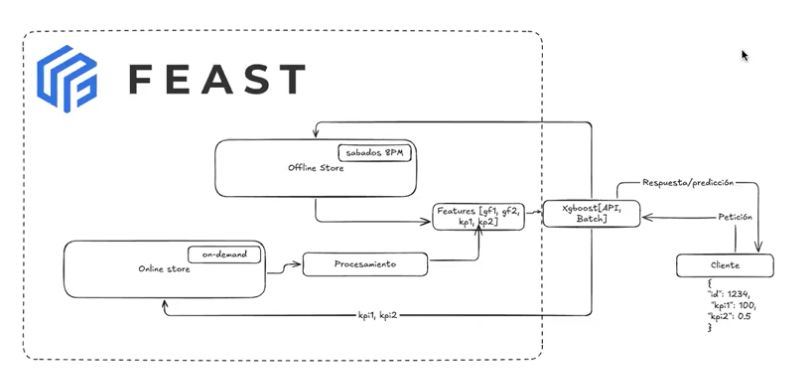

In [169]:
from IPython.display import display, Image
display(Image("./feast_2.jpeg"))